 # Supervised Learning: More Regression

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#Please read the sklearn documentation if you need to figure out the inputs and outputs of these functions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

 ## PART 1: SIMPLE LINEAR REGRESSION



 We'll analyze the relationship between study hours and exam scores using three different methods.

Dataset:
   Hours_Studied  Exam_Score
0            1.5          45
1            2.0          51
2            2.5          58
3            3.0          62
4            3.5          68
5            4.0          73
6            4.5          78
7            5.0          84
8            5.5          88
9            6.0          93


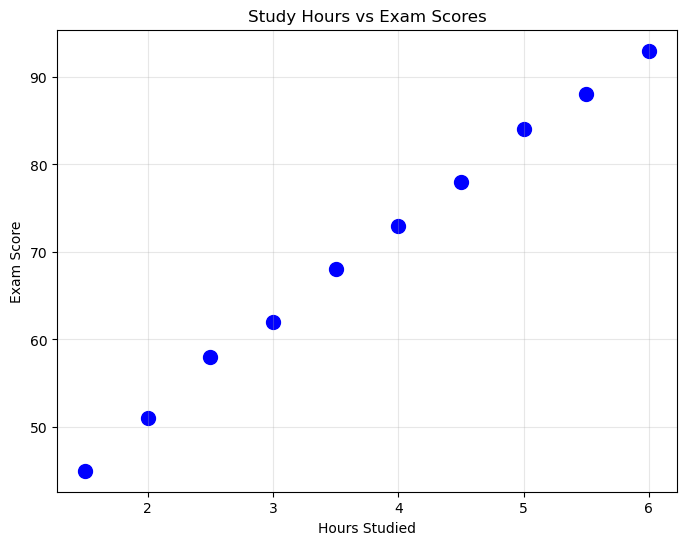

In [4]:
# Dataset: Study Hours vs Exam Scores
data = {
    'Hours_Studied': [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0],
    'Exam_Score': [45, 51, 58, 62, 68, 73, 78, 84, 88, 93]
}
df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(df['Hours_Studied'], df['Exam_Score'], color='blue', s=100)
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Scores')
plt.grid(True, alpha=0.3)
plt.show()


 ### TASK 1: Manual Least Squares Calculation



 Calculate the slope (m) and intercept (b) for y = mx + b using the **FIRST 5 DATA POINTS ONLY**.



 **Formulas:**

 - Slope: $m = \frac{n\sum xy - \sum x \sum y}{n\sum x^2 - (\sum x)^2}$

 - Intercept: $b = \frac{\sum y - m\sum x}{n}$

In [6]:
# Use first 5 data points
x_manual = df['Hours_Studied'][:5].values
y_manual = df['Exam_Score'][:5].values

n = len(x_manual)

# TODO: Calculate sums needed
sum_x = x_manual.sum()
sum_y = y_manual.sum()
sum_xy = (x_manual * y_manual).sum()
sum_x_squared = (x_manual**2).sum()

# TODO: Calculate slope and intercept using formulas above
m_manual = (n * sum_xy - sum_x * sum_y) / (n * sum_x_squared - sum_x**2)
b_manual = (sum_y - m_manual * sum_x) / n

print("TASK 1 - Manual Calculation (first 5 points):")
print(f"Slope (m): {m_manual}")
print(f"Intercept (b): {b_manual}")
print(f"Equation: y = {m_manual:.2f}x + {b_manual:.2f}\n")

# TODO: Make predictions and calculate errors
y_pred_manual = m_manual * x_manual + b_manual
mae_manual = (abs(y_manual - y_pred_manual)).mean()
mse_manual = ((y_manual - y_pred_manual**2).mean())

print(f"MAE: {mae_manual:.2f}")
print(f"MSE: {mse_manual:.2f}")


TASK 1 - Manual Calculation (first 5 points):
Slope (m): 11.4
Intercept (b): 28.3
Equation: y = 11.40x + 28.30

MAE: 0.48
MSE: -3234.42


 ### TASK 2: NumPy lstsq (Full Dataset)



 Use `np.linalg.lstsq` to find the best fit line for all 10 data points.



 #### Why Add a Column of Ones?



 When we use `np.linalg.lstsq`, we're solving the matrix equation: **Xβ = y**



 For a linear regression equation **y = mx + b**, we need to find both:

 - **m** (slope)

 - **b** (intercept)



 The design matrix must be structured so that matrix multiplication gives us: **b·1 + m·x**



 ```

 Design Matrix (X):        Coefficients (β):     Result (y):

 [1  x₁]                   [b]                   [b·1 + m·x₁]

 [1  x₂]           ×       [m]          =        [b·1 + m·x₂]

 [1  x₃]                                         [b·1 + m·x₃]

 ...

 ```



 **Key Points:**

 - The column of ones multiplies with the intercept **b** to add that constant term to each prediction

 - The column of x values multiplies with the slope **m** to add the variable component

 - **Without the ones column:** We'd only fit lines through the origin (b=0): y = mx

 - **With the ones column:** We can fit any line: y = mx + b

In [7]:
# TODO: Prepare the design matrix
x_values = df['Hours_Studied'].values
# Hint: Use np.column_stack to combine a column of ones with the Hours_Studied values
X_numpy = np.column_stack((np.ones(len(x_values)), x_values))
y_numpy = df['Exam_Score'].values

# TODO: Use np.linalg.lstsq
solution, residuals, rank, s = np.linalg.lstsq(X_numpy, y_numpy, rcond=None)

# TODO: Extract coefficients
b_numpy = b_numpy = solution[0]
m_numpy = m_numpy = solution[1]

print("TASK 2 - NumPy lstsq (all 10 points):")
print(f"Slope (m): {m_numpy}")
print(f"Intercept (b): {b_numpy}")
print(f"Equation: y = {m_numpy:.2f}x + {b_numpy:.2f}\n")

# TODO: Calculate predictions and errors
y_pred_numpy = X_numpy @ solution
mae_numpy = np.abs(y_numpy - y_pred_numpy).mean()
mse_numpy = ((y_numpy - y_pred_numpy)**2).mean()

print(f"MAE: {mae_numpy:.2f}")
print(f"MSE: {mse_numpy:.2f}")


TASK 2 - NumPy lstsq (all 10 points):
Slope (m): 10.593939393939404
Intercept (b): 30.272727272727266
Equation: y = 10.59x + 30.27

MAE: 0.61
MSE: 0.52


 ### TASK 3: Scikit-learn LinearRegression (Full Dataset)



 Use sklearn's `LinearRegression` class.



 **Note:** sklearn automatically handles the intercept internally (with `fit_intercept=True` by default), so we don't need to add a column of ones!

In [9]:
# TODO: Reshape X for sklearn (needs 2D array)
X_sklearn = df['Hours_Studied'].values.reshape(-1, 1)
y_sklearn = df['Exam_Score'].values

# TODO: Create and fit the model
model = LinearRegression()
# TODO: Fit the model
model.fit(X_sklearn, y_sklearn)

# TODO: Extract coefficients
m_sklearn = model.coef_[0]
b_sklearn = model.intercept_

print("TASK 3 - Sklearn LinearRegression (all 10 points):")
print(f"Slope (m): {m_sklearn}")
print(f"Intercept (b): {b_sklearn}")
print(f"Equation: y = {m_sklearn:.2f}x + {b_sklearn:.2f}\n")

# TODO: Calculate predictions and errors
y_pred_sklearn = model.predict(X_sklearn)
mae_sklearn = mean_absolute_error(y_sklearn, y_pred_sklearn)
mse_sklearn = mean_squared_error(y_sklearn, y_pred_sklearn)

print(f"MAE: {mae_sklearn:.2f}")
print(f"MSE: {mse_sklearn:.2f}")


TASK 3 - Sklearn LinearRegression (all 10 points):
Slope (m): 10.593939393939388
Intercept (b): 30.272727272727295
Equation: y = 10.59x + 30.27

MAE: 0.61
MSE: 0.52


 ### TASK 4: Comparison and Discussion

In [10]:
print("="*70)
print("COMPARISON OF ALL THREE METHODS:")
print("="*70)
print(f"{'Method':<30} {'Slope':<12} {'Intercept':<12} {'MAE':<10} {'MSE':<10}")
print("-"*70)
# TODO: Fill in the comparison table with your results
print(f"{'Manual (5 points)':<30} {m_manual:<12.4f} {b_manual:<12.4f} {mae_manual:<10.2f} {mse_manual:<10.2f}")
print(f"{'NumPy (10 points)':<30} {m_numpy:<12.4f} {b_numpy:<12.4f} {mae_numpy:<10.2f} {mse_numpy:<10.2f}")
print(f"{'Sklearn (10 points)':<30} {m_sklearn:<12.4f} {b_sklearn:<12.4f} {mae_sklearn:<10.2f} {mse_sklearn:<10.2f}")

COMPARISON OF ALL THREE METHODS:
Method                         Slope        Intercept    MAE        MSE       
----------------------------------------------------------------------
Manual (5 points)              11.4000      28.3000      0.48       -3234.42  
NumPy (10 points)              10.5939      30.2727      0.61       0.52      
Sklearn (10 points)            10.5939      30.2727      0.61       0.52      


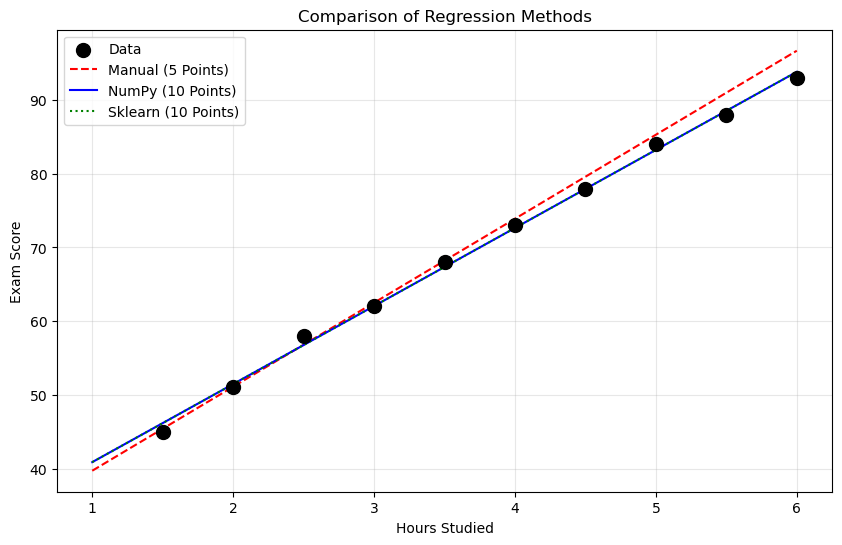

In [13]:
# TODO: Plot all three regression lines
plt.figure(figsize=(10, 6))
plt.scatter(df['Hours_Studied'], df['Exam_Score'], color='black', s=100, label='Data', zorder=3)

# TODO: Create x range for plotting
x_range = np.linspace(1, 6, 100)

# TODO: Plot each regression line with different styles
# Hint: Use different linestyles: '--', '-', ':'
plt.plot(x_range, m_manual * x_range + b_manual,
         label='Manual (5 Points)', color='red', linestyle='--')
plt.plot(x_range, m_numpy * x_range + b_numpy,
         label='NumPy (10 Points)', color='blue', linestyle='-')
plt.plot(x_range, m_sklearn * x_range + b_sklearn,
         label='Sklearn (10 Points)', color='green', linestyle=':')

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Comparison of Regression Methods')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


 ### Discussion Questions



 **1. Why do the manual calculations differ from NumPy and sklearn?**



 *YOUR ANSWER:*

The manual calculations only used the first 5 data points while the NumPy and sklearn calculations used all 10, so the line of best fit for the manual calculations will defer from the line of best fit for the NumPy and sklearn calculations.

 ---



 **2. Why are NumPy and sklearn results nearly identical?**



 *YOUR ANSWER:*

Both of them used the same data, so they will have the identical lines of best fit.

 ---



 **3. Which method produced the lowest error? Why?**



 *YOUR ANSWER:*

NumPy and sklearn produced the lowest error because they used all 10 data points, so the MAE/MSE of those lines will be lower than the MAE/MSE of the manual line of best fit.

 ---

 ## PART 2: MULTIPLE LINEAR REGRESSION



 Now we'll predict house prices using multiple features.

In [ ]:
# Dataset: House Prices
house_data = {
    'Size_sqft': [1200, 1500, 1800, 2000, 2200, 2500, 2800, 3000, 3200, 3500,
                  1300, 1600, 1900, 2100, 2400, 2600, 2900, 3100, 3300, 3600],
    'Bedrooms': [2, 3, 3, 3, 4, 4, 4, 4, 5, 5,
                 2, 3, 3, 4, 4, 4, 4, 5, 5, 5],
    'Age_years': [15, 20, 10, 5, 8, 3, 12, 6, 15, 2,
                  18, 12, 8, 10, 5, 7, 4, 9, 11, 1],
    'Price_1000s': [180, 210, 250, 280, 310, 350, 360, 400, 420, 480,
                    190, 230, 270, 300, 340, 370, 390, 430, 450, 510]
}
house_df = pd.DataFrame(house_data)

print("House Price Dataset:")
print(house_df)


 ### TASK 5: Justify Multiple Linear Regression



 Calculate correlations to understand relationships between features and price.

In [ ]:
print("Correlations with Price:")
# TODO: Calculate correlation between each feature and price
for col in ['Size_sqft', 'Bedrooms', 'Age_years']:
    corr = df[col].cor(df['Price'])
    print(f"{col}: {corr:.3f}")


 **Why should we use multiple linear regression instead of simple linear regression?**



 *YOUR ANSWER:*

Multiple linear regression reduces the error becuase simple linear regression only accounts for one feature, but house prices are influenced by many factors, so multiple linear regression would be better as it accounts for many different features which would reduce any errors.

 ---

 ### TASK 6: Implement Multiple Linear Regression

In [ ]:
# TODO: Prepare features and target
X_multi = # TODO: Select feature columns
y_multi = # TODO: Select target column

# TODO: Split into training and testing sets (80-20 split)
# The purpose of splitting the data into a training and testing set is to save some of the data to test the model that we trained.
# The test data set needs to be separate from the training data so we can simulate "new" situations before we put our model out in the real world.
# Hint: There is a very helpful sklearn method you should use for this step
X_train, X_test, y_train, y_test = # TODO

# TODO: Create and train the model
mlr_model = # TODO: Create LinearRegression object
# TODO: Fit the model

# TODO: Make predictions
y_train_pred = # TODO: Predictions on training set
y_test_pred = # TODO: Predictions on test set

# TODO: Extract coefficients
coefficients = # TODO: Get coefficients
intercept = # TODO: Get intercept

print("Model Coefficients:")
print(f"Intercept: {intercept:.2f}")
for i, col in enumerate(X_multi.columns):
    print(f"{col}: ???")  # TODO: Fill in actual coefficient

print("\nModel Equation:")
print("Price = ??? + ???*Size + ???*Bedrooms + ???*Age")  # TODO: Complete


 ### TASK 7: Calculate and Interpret Errors

In [ ]:
# TODO: Calculate training errors (how far were predictions from the real prices)
train_mae = # TODO
train_mse = # TODO
train_rmse = # TODO: np.sqrt(train_mse)

# TODO: Calculate testing errors (how far were predictions from the real prices)
test_mae = # TODO
test_mse = # TODO
test_rmse = # TODO

print("Training Set Performance:")
print(f"MAE: $???k")  # TODO: Fill in
print(f"MSE: $???k²")  # TODO: Fill in
print(f"RMSE: $???k")  # TODO: Fill in

print("\nTest Set Performance:")
print(f"MAE: $???k")  # TODO: Fill in
print(f"MSE: $???k²")  # TODO: Fill in
print(f"RMSE: $???k")  # TODO: Fill in


 ### TASK 8: Visualize Results

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.6, s=100, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price ($1000s)')
axes[0].set_ylabel('Predicted Price ($1000s)')
axes[0].set_title('Training Set: Actual vs Predicted')
axes[0].grid(True, alpha=0.3)

# Testing set
# TODO: Complete the test set plot
axes[1].scatter(# TODO
axes[1].plot(# TODO
axes[1].set_xlabel('Actual Price ($1000s)')
axes[1].set_ylabel('Predicted Price ($1000s)')
axes[1].set_title('Test Set: Actual vs Predicted')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


 ### Final Discussion Questions



 **1. How do the training and test errors compare? What does this tell you? (Recall our discussion on overfitting and underfitting from last week)**



 *YOUR ANSWER:*



 ---



 **2. Which feature has the strongest effect on house price? How can you tell?**



 *YOUR ANSWER:*



 ---



 **3. What is one limitation of this model?**



 *YOUR ANSWER:*



 ---